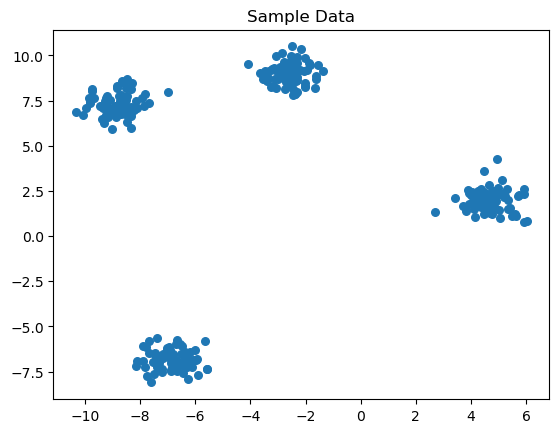

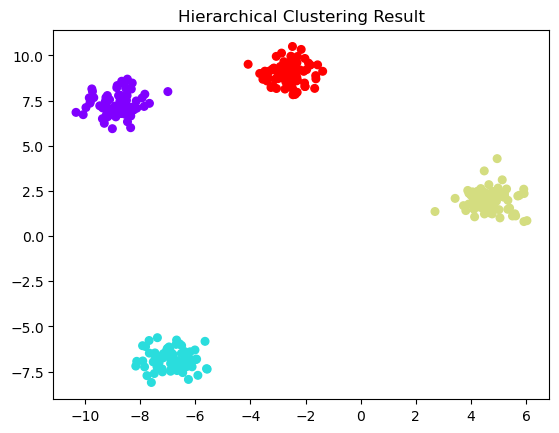

Evaluation Metrics:
Silhouette Score: 0.876 (Higher is better, max=1)
Davies–Bouldin Index: 0.174 (Lower is better)


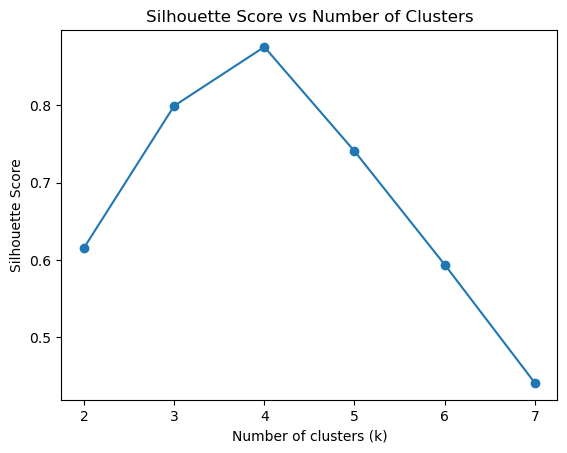

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score


X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)


plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Sample Data")
plt.show()


model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X)


plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=30)
plt.title("Hierarchical Clustering Result")
plt.show()


silhouette_avg = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)

print("Evaluation Metrics:")
print(f"Silhouette Score: {silhouette_avg:.3f} (Higher is better, max=1)")
print(f"Davies–Bouldin Index: {db_index:.3f} (Lower is better)")


scores = []
for k in range(2, 8):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    scores.append(sil)

plt.plot(range(2, 8), scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()